# 10 - Comparación de Predicciones Avanzadas

## Evaluación de distintos problemas de Machine Learning sobre el dataset logístico V3

En este notebook se prueban distintos enfoques de Machine Learning utilizando el dataset mejorado `dataset_modelo_v3.csv`.

El objetivo es identificar qué tipo de predicción presenta mejores resultados y mayor sentido operacional para el proyecto.

Las predicciones evaluadas serán:

1. Riesgo operacional alto (clasificación)
2. Entrega tardía V3 (clasificación)
3. Multiclase de incidencias (clasificación)
4. Riesgo operacional (regresión)

Al final se comparan todas las métricas para seleccionar el enfoque más defendible.


# 1. Importación de librerías

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Métricas clasificación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Métricas regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Modelos clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Modelos regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


# 2. Carga del dataset V3

In [46]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 3. Creación de nuevos targets

Aquí se crean las nuevas predicciones avanzadas.


In [47]:
# Riesgo operacional alto.
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

# Entrega tardía V3.
percentil_entrega = df["dias_entrega"].quantile(0.75)

df["entrega_tardia_v3"] = np.where(
    df["dias_entrega"] >= percentil_entrega,
    1,
    0
)

# Multiclase incidencias.
df["incidencia_multiclase"] = np.select(
    [
        df["cantidad_incidencias"] == 0,
        df["cantidad_incidencias"] == 1,
        df["cantidad_incidencias"] >= 2
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

print("Targets creados correctamente.")


Targets creados correctamente.


# 4. Variables predictoras

In [48]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [c for c in variables_base if c in df.columns]

print("Cantidad de variables:", len(variables_modelo))


Cantidad de variables: 29


# 5. Funciones auxiliares

In [49]:
def crear_preprocesador(X):

    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 6. Función para clasificación

In [50]:
def evaluar_clasificacion(nombre_target):

    X = df[variables_modelo]
    y = df[nombre_target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocesador = crear_preprocesador(X)

    modelos = {
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=8,
            class_weight="balanced"
        ),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(
            class_weight="balanced"
        ),
        "Gaussian NB": GaussianNB()
    }

    resultados = []

    for nombre, modelo in modelos.items():

        pipeline = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        resultados.append({
            "target": nombre_target,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            "recall": recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            "f1_score": f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            )
        })

    return pd.DataFrame(resultados)


# 7. Función para regresión

In [51]:
def evaluar_regresion(nombre_target):

    X = df[variables_modelo]
    y = df[nombre_target]

    datos_regresion = pd.concat([X, y], axis=1).dropna(subset=[nombre_target])

    X = datos_regresion[variables_modelo]
    y = datos_regresion[nombre_target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    preprocesador = crear_preprocesador(X)

    modelos = {
        "Linear Regression": LinearRegression(),
        "Decision Tree Regressor": DecisionTreeRegressor(
            random_state=42,
            max_depth=6
        ),
        "Random Forest Regressor": RandomForestRegressor(
            random_state=42,
            n_estimators=200,
            max_depth=8
        ),
        "KNN Regressor": KNeighborsRegressor(),
        "SVR": SVR()
    }

    resultados = []

    for nombre, modelo in modelos.items():

        pipeline = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        resultados.append({
            "target": nombre_target,
            "modelo": nombre,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": rmse,
            "r2": r2_score(y_test, y_pred)
        })

    return pd.DataFrame(resultados)


# 8. Predicción 1 - Riesgo operacional alto

In [52]:
tabla_riesgo_alto = evaluar_clasificacion(
    "riesgo_operacional_alto"
)

tabla_riesgo_alto.sort_values(by="f1_score", ascending=False)


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,riesgo_operacional_alto,Random Forest,0.975,0.976551,0.976052,0.975,0.975246
1,riesgo_operacional_alto,Decision Tree,0.965,0.963036,0.966240,0.965,0.965344
0,riesgo_operacional_alto,Logistic Regression,0.945,0.956683,0.952442,0.945,0.946468
4,riesgo_operacional_alto,SVM,0.925,0.943438,0.939206,0.925,0.927705
3,riesgo_operacional_alto,KNN,0.915,0.895459,0.917175,0.915,0.915836
5,riesgo_operacional_alto,Gaussian NB,0.900,0.933775,0.928986,0.900,0.904928


## Análisis

Esta predicción busca identificar envíos con alto riesgo operacional.

A diferencia de las incidencias binarias, este target probablemente tiene relaciones más claras con variables como:

- velocidad;
- sobrecarga;
- distancia;
- complejidad de ruta.


# 9. Predicción 2 - Entrega tardía V3

In [53]:
tabla_entrega_v3 = evaluar_clasificacion(
    "entrega_tardia_v3"
)

tabla_entrega_v3.sort_values(by="f1_score", ascending=False)


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
3,entrega_tardia_v3,KNN,0.925,0.500000,0.855625,0.925,0.888961
2,entrega_tardia_v3,Random Forest,0.925,0.500000,0.855625,0.925,0.888961
4,entrega_tardia_v3,SVM,0.810,0.499099,0.861047,0.810,0.833958
1,entrega_tardia_v3,Decision Tree,0.725,0.575676,0.877404,0.725,0.785655
5,entrega_tardia_v3,Gaussian NB,0.620,0.457658,0.851676,0.620,0.709675
0,entrega_tardia_v3,Logistic Regression,0.615,0.393694,0.837534,0.615,0.705428


## Análisis

Esta versión utiliza un criterio más robusto para definir retrasos, basado en percentiles del dataset.

Esto busca evitar el desbalance extremo observado anteriormente.


# 10. Predicción 3 - Multiclase incidencias

In [54]:
tabla_multiclase = evaluar_clasificacion(
    "incidencia_multiclase"
)

tabla_multiclase.sort_values(by="f1_score", ascending=False)


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,incidencia_multiclase,Random Forest,0.830,0.348851,0.764256,0.830,0.773797
3,incidencia_multiclase,KNN,0.820,0.344859,0.745167,0.820,0.767816
4,incidencia_multiclase,SVM,0.570,0.323868,0.716322,0.570,0.623269
1,incidencia_multiclase,Decision Tree,0.520,0.373962,0.753685,0.520,0.580622
0,incidencia_multiclase,Logistic Regression,0.490,0.318202,0.728190,0.490,0.564143
5,incidencia_multiclase,Gaussian NB,0.445,0.359829,0.748415,0.445,0.550434


## Análisis

Aquí el problema deja de ser binario y pasa a clasificar:

- sin incidencias;
- incidencia leve;
- múltiples incidencias.

Esto puede capturar mejor distintos comportamientos operacionales.


# 11. Predicción 4 - Riesgo operacional (regresión)

In [55]:
tabla_regresion = evaluar_regresion(
    "riesgo_operacional"
)

tabla_regresion.sort_values(by="rmse")


,target,modelo,mae,rmse,r2
2,riesgo_operacional,Random Forest Regressor,60.824812,117.924183,0.995841
1,riesgo_operacional,Decision Tree Regressor,206.714253,342.951633,0.964822
3,riesgo_operacional,KNN Regressor,496.214586,787.794337,0.814378
0,riesgo_operacional,Linear Regression,699.171583,1091.048725,0.643966
4,riesgo_operacional,SVR,1130.906145,1871.708944,-0.047804


## Análisis

Esta predicción busca estimar directamente el nivel de riesgo operacional.

Como el target fue construido matemáticamente, existe mayor probabilidad de que los modelos encuentren relaciones útiles.


# 12. Comparación global de clasificación

In [56]:
tabla_clasificacion = pd.concat([
    tabla_riesgo_alto,
    tabla_entrega_v3,
    tabla_multiclase
])

tabla_clasificacion.sort_values(
    by="f1_score",
    ascending=False
)


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
2,riesgo_operacional_alto,Random Forest,0.975,0.976551,0.976052,0.975,0.975246
1,riesgo_operacional_alto,Decision Tree,0.965,0.963036,0.966240,0.965,0.965344
0,riesgo_operacional_alto,Logistic Regression,0.945,0.956683,0.952442,0.945,0.946468
4,riesgo_operacional_alto,SVM,0.925,0.943438,0.939206,0.925,0.927705
3,riesgo_operacional_alto,KNN,0.915,0.895459,0.917175,0.915,0.915836
5,riesgo_operacional_alto,Gaussian NB,0.900,0.933775,0.928986,0.900,0.904928
3,entrega_tardia_v3,KNN,0.925,0.500000,0.855625,0.925,0.888961
2,entrega_tardia_v3,Random Forest,0.925,0.500000,0.855625,0.925,0.888961
4,entrega_tardia_v3,SVM,0.810,0.499099,0.861047,0.810,0.833958
1,entrega_tardia_v3,Decision Tree,0.725,0.575676,0.877404,0.725,0.785655


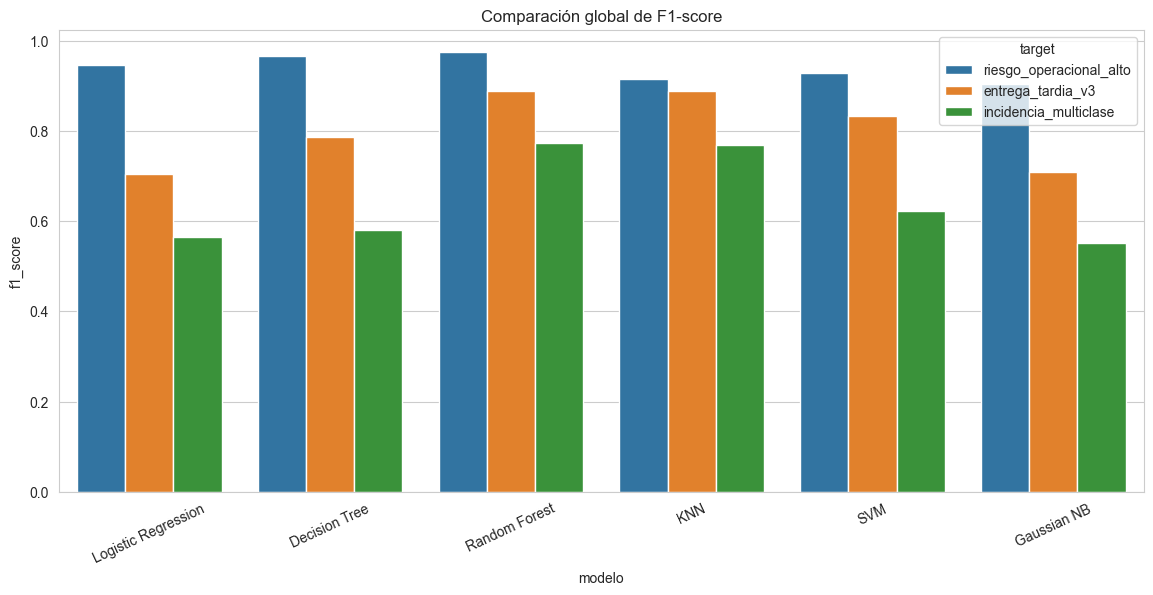

In [57]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=tabla_clasificacion,
    x="modelo",
    y="f1_score",
    hue="target"
)

plt.title("Comparación global de F1-score")
plt.xticks(rotation=25)

plt.show()


# 13. Comparación global de regresión

In [58]:
tabla_regresion.sort_values(by="rmse")


,target,modelo,mae,rmse,r2
2,riesgo_operacional,Random Forest Regressor,60.824812,117.924183,0.995841
1,riesgo_operacional,Decision Tree Regressor,206.714253,342.951633,0.964822
3,riesgo_operacional,KNN Regressor,496.214586,787.794337,0.814378
0,riesgo_operacional,Linear Regression,699.171583,1091.048725,0.643966
4,riesgo_operacional,SVR,1130.906145,1871.708944,-0.047804


# 14. Selección de mejor predicción

In [59]:
mejor_clasificacion = tabla_clasificacion.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_regresion = tabla_regresion.sort_values(
    by="rmse",
    ascending=True
).iloc[0]

print("MEJOR CLASIFICACIÓN")
display(mejor_clasificacion)

print("\nMEJOR REGRESIÓN")
display(mejor_regresion)


MEJOR CLASIFICACIÓN



target               riesgo_operacional_alto
modelo                         Random Forest
accuracy                               0.975
balanced_accuracy                   0.976551
precision                           0.976052
recall                                 0.975
f1_score                            0.975246
Name: 2, dtype: object


MEJOR REGRESIÓN



target         riesgo_operacional
modelo    Random Forest Regressor
mae                     60.824812
rmse                   117.924183
r2                       0.995841
Name: 2, dtype: object

# 15. Conclusiones finales

En este notebook se compararon distintos enfoques avanzados de Machine Learning sobre el dataset logístico V3.

Se probaron:

## Clasificación
- riesgo operacional alto;
- entrega tardía V3;
- incidencias multiclase.

## Regresión
- riesgo operacional continuo.

La comparación final permitirá identificar:

- qué target presenta mayor separabilidad;
- qué problema tiene más sentido operacional;
- y qué enfoque resulta más defendible para continuar con optimización de hiperparámetros.

El siguiente paso será continuar únicamente con la predicción que entregue mejores métricas y mejor interpretación de negocio.


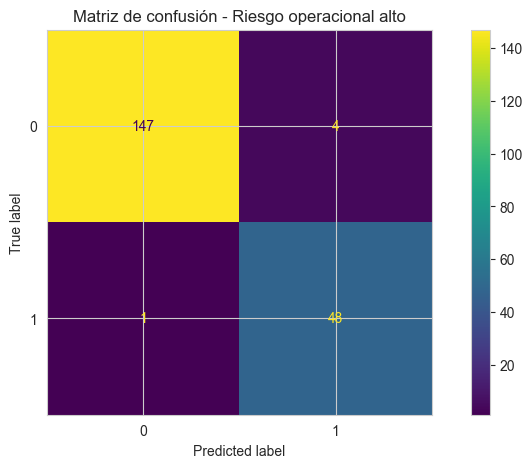

===== CLASSIFICATION REPORT =====

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.92      0.98      0.95        49

    accuracy                           0.97       200
   macro avg       0.96      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:92                                                                                   │
│                                                                                                  │
│    89                                                                                            │
│    90 modelo_rf = modelo_final.named_steps["modelo"]                                             │
│    91                                                                                            │
│ ❱  92 importancias = pd.DataFrame({                                                              │
│    93 │   "variable": variables_modelo,                                                          │
│    94 │   "importancia": modelo_rf.feature_importances_                                          │
│    95 })                                                                                         │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\pa │
│ ndas\core\frame.py:782 in __init__                                                               │
│                                                                                                  │
│     779 │   │                                                                                    │
│     780 │   │   elif isinstance(data, dict):                                                     │
│     781 │   │   │   # GH#38939 de facto copy defaults to False only in non-dict cases            │
│ ❱   782 │   │   │   mgr = dict_to_mgr(data, index, columns, dtype=dtype, copy=copy, typ=manager) │
│     783 │   │   elif isinstance(data, ma.MaskedArray):                                           │
│     784 │   │   │   from numpy.ma import mrecords                                                │
│     785                                                                                          │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\pa │
│ ndas\core\internals\construction.py:503 in dict_to_mgr                                           │
│                                                                                                  │
│    500 │   │   │   # dtype check to exclude e.g. range objects, scalars                          │
│    501 │   │   │   arrays = [x.copy() if hasattr(x, "dtype") else x for x in arrays]             │
│    502 │                                                                                         │
│ ❱  503 │   return arrays_to_mgr(arrays, columns, index, dtype=dtype, typ=typ, consolidate=copy)  │
│    504                                                                                           │
│    505                                                                                           │
│    506 def nested_data_to_arrays(                                                                │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\pa │
│ ndas\core\internals\construction.py:114 in arrays_to_mgr                                         │
│                                                                                                  │
│    111 │   if verify_integrity:                                                                  │
│    112 │   │   # figure out the index, if necessary                                              │
│    113 │   │   if index is None:                                                                 │
│ ❱  114 │   │   │   index = _extract_index(arrays)          

In [60]:
# =========================================
# ANÁLISIS FINAL DEL MEJOR MODELO
# Riesgo operacional alto - Random Forest
# =========================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# =========================================
# DATOS
# =========================================

X = df[variables_modelo]
y = df["riesgo_operacional_alto"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# PREPROCESAMIENTO
# =========================================

preprocesador = crear_preprocesador(X)

# =========================================
# MODELO FINAL
# =========================================

modelo_final = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ))
])

# Entrenamiento
modelo_final.fit(X_train, y_train)

# Predicciones
y_pred = modelo_final.predict(X_test)

# =========================================
# MATRIZ DE CONFUSIÓN
# =========================================

matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz
)

disp.plot()

plt.title(
    "Matriz de confusión - Riesgo operacional alto"
)

plt.show()

# =========================================
# CLASSIFICATION REPORT
# =========================================

print("===== CLASSIFICATION REPORT =====\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# =========================================
# IMPORTANCIA DE VARIABLES
# =========================================

modelo_rf = modelo_final.named_steps["modelo"]

importancias = pd.DataFrame({
    "variable": variables_modelo,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="importancia",
    ascending=False
)

print("\n===== TOP VARIABLES IMPORTANTES =====\n")

display(importancias.head(15))

# =========================================
# GRÁFICO IMPORTANCIA
# =========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(15),
    x="importancia",
    y="variable"
)

plt.title(
    "Variables más importantes - Random Forest"
)

plt.xlabel("Importancia")

plt.ylabel("Variable")

plt.show()

===== TOP VARIABLES IMPORTANTES =====


,variable,importancia
8,num__uso_capacidad_kg,0.250513
14,num__sobrecarga_kg,0.104736
13,num__vehiculo_exigido,0.087762
4,num__capacidad_kg,0.082429
0,num__distancia_km,0.079627
19,num__distancia_km_log,0.061197
12,num__riesgo_velocidad,0.047760
23,num__riesgo_velocidad_log,0.033918
18,num__peso_kg_log,0.033721
2,num__peso_kg,0.031080


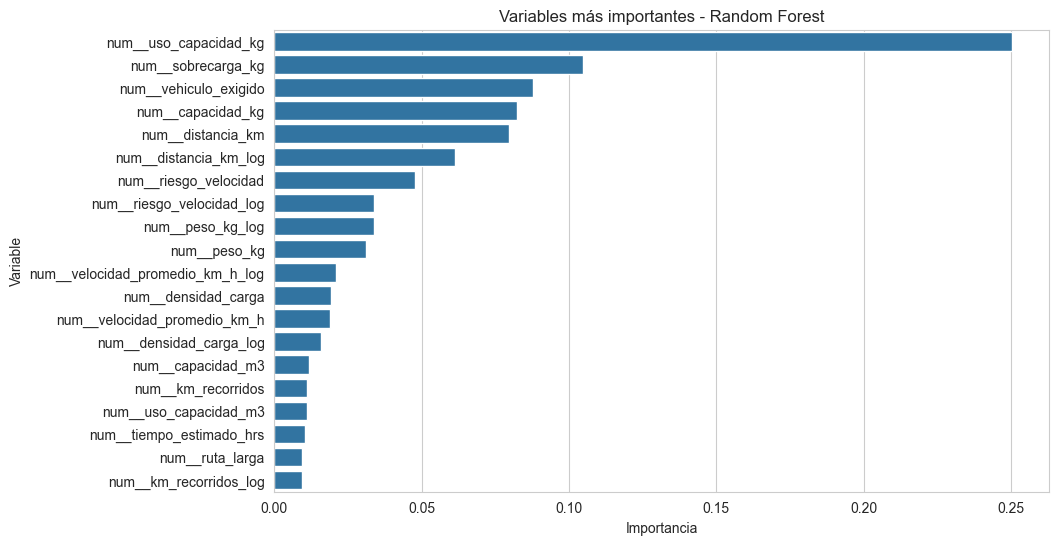

In [61]:
# =========================================
# IMPORTANCIA DE VARIABLES CORREGIDA
# =========================================

modelo_rf = modelo_final.named_steps["modelo"]
preprocesador_final = modelo_final.named_steps["preprocesamiento"]

# Obtener nombres reales después del preprocesamiento
nombres_features = preprocesador_final.get_feature_names_out()

importancias = pd.DataFrame({
    "variable": nombres_features,
    "importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="importancia",
    ascending=False
)

print("===== TOP VARIABLES IMPORTANTES =====")

display(importancias.head(20))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(20),
    x="importancia",
    y="variable"
)

plt.title("Variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()